<a href="https://colab.research.google.com/github/thomsmbockchildGod/Assignment11AI/blob/main/Assignment11AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Assignment 11 Overall Pipeline: Image(data)-Preprocessing- Model training- Prediction-Evaluation

In [ ]:
# load data (image)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
!unzip -o images.zip

Archive:  images.zip
   creating: images/dalmatian/
  inflating: images/dalmatian/image_0001.jpg  
  inflating: images/dalmatian/image_0002.jpg  
  inflating: images/dalmatian/image_0003.jpg  
  inflating: images/dalmatian/image_0004.jpg  
  inflating: images/dalmatian/image_0005.jpg  
  inflating: images/dalmatian/image_0006.jpg  
  inflating: images/dalmatian/image_0007.jpg  
  inflating: images/dalmatian/image_0008.jpg  
  inflating: images/dalmatian/image_0009.jpg  
  inflating: images/dalmatian/image_0010.jpg  
  inflating: images/dalmatian/image_0011.jpg  
  inflating: images/dalmatian/image_0012.jpg  
  inflating: images/dalmatian/image_0013.jpg  
  inflating: images/dalmatian/image_0014.jpg  
  inflating: images/dalmatian/image_0015.jpg  
  inflating: images/dalmatian/image_0016.jpg  
  inflating: images/dalmatian/image_0017.jpg  
  inflating: images/dalmatian/image_0018.jpg  
  inflating: images/dalmatian/image_0019.jpg  
  inflating: images/dalmatian/image_0020.jpg  
  inflat

In [ ]:
data_dir="images"

images=[]
labels=[]

for label in os.listdir(data_dir):
  class_path=os.path.join(data_dir,label)
  if os.path.isdir(class_path):
    for img_file in os.listdir(class_path):
      img_path=os.path.join(class_path,img_file)
      try:
        img=cv2.imread(img_path)
        img=cv2.resize(img,(64,64))
        images.append(img)
        labels.append(label)
      except:
        continue

In [ ]:
#creating feature and target variables
X=np.array(images)
Y=np.array(labels)
print(X.shape)

(309, 64, 64, 3)


In [ ]:
#Preprocessing using the flattening and the scaling

#flattening

X=X.reshape(X.shape[0],-1)

#scaling

from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
#model selection/splitting and training

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(X_scaled,Y,test_size=0.3,random_state=42)

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

model_svc=SVC(kernel='rbf')

model_rfc=RandomForestClassifier(n_estimators=100,random_state=42)

model_svc.fit(x_train,y_train)

model_rfc.fit(x_train,y_train)


RandomForestClassifier(random_state=42)

In [ ]:
# model prediction and evaluation

from sklearn.metrics import confusion_matrix,classification_report

y_pred_rfc=model_rfc.predict(x_test)

y_pred_svc=model_svc.predict(x_test)

cm_rfc=confusion_matrix(y_test,y_pred_rfc)

cm_svc=confusion_matrix(y_test,y_pred_svc)

cr_rfc=classification_report(y_test,y_pred_rfc)

cr_svc=classification_report(y_test,y_pred_svc)

print(f"random forest confusion matrix is:\n {cm_rfc}")

print(f"support vector confusion matrix is:\n {cm_svc}")

print(f"random forest classification report is:\n {cr_rfc}")

print(f"support vector classification report is:\n {cr_svc}")

random forest confusion matrix is:
 [[15  0  2  3  0]
 [ 0 15  2  1  1]
 [ 1  0  9  1  4]
 [ 1  1  0  8  2]
 [ 0  0  3  1 23]]
support vector confusion matrix is:
 [[15  1  0  3  1]
 [ 1 14  1  2  1]
 [ 1  0 13  1  0]
 [ 2  1  0  8  1]
 [ 0  0  1  1 25]]
random forest classification report is:
               precision    recall  f1-score   support

   dalmatian       0.88      0.75      0.81        20
 dollar_bill       0.94      0.79      0.86        19
       pizza       0.56      0.60      0.58        15
 soccer_ball       0.57      0.67      0.62        12
   sunflower       0.77      0.85      0.81        27

    accuracy                           0.75        93
   macro avg       0.74      0.73      0.73        93
weighted avg       0.77      0.75      0.76        93

support vector classification report is:
               precision    recall  f1-score   support

   dalmatian       0.79      0.75      0.77        20
 dollar_bill       0.88      0.74      0.80        19
       piz

Of all the predicted positive, random forest model is 88% right when it predicts that an image belongs to the dog category (dalmatian) and 12% wrong (False positive).
Of all actual positive, random forest model correctly predicted (75%) that an image belongs to the dog category and failed to predict that an image belongs to the dog category (25% False Negative)
F1-score of 81% indicates that the model is balanced

of all the predicted positive, random forest model is 94% right when it predicts that an image belongs to the dollar_bill category and 6% wrong (False positive).
Of all actual positive, random forest model correctly predicted (79%) that an image belongs to the dollar_bill category and failed to predict that an image belongs to the dollar_bill category (25% False Negative)
F1-score of 86% indicates that the model is balanced

of all the predicted positive, random forest model is 56% right when it predicts that an image belongs to pizza category and 44% wrong (False positive).
Of all actual positive, random forest model correctly predicted (60%) that an image belongs to pizza category and failed to predict that an image belongs to pizza category (40% False Negative)
F1-score of 58% still indicates that the model is balanced
Of all the predicted positive, random forest model is 57% right when it predicts that an image belongs to soccer_ball category and 43% wrong (False positive).
Of all actual positive, random forest model correctly predicted (67%) that an image belongs to soccer_ball category and failed to predict that an image belongs to soccer_ball category (33% False Negative)
F1-score of 62% still indicates that the model is balanced

Of all the predicted positive, random forest model is 77% right when it predicts that an image belongs to sunflower category and 23% wrong (False positive).
Of all actual positive, random forest model correctly predicted (85%) that an image belongs to sunflower category and failed to predict that an image belongs to sunflower category (15% False Negative)
F1-score of 81% still indicates that the model is balanced


of all the predicted positive, SVC model is 79% right when it predicts that an image belongs to the dog category (dalmatian) and 21% wrong (False positive).
Of all actual positive, SVC model correctly predicted (75%) that an image belongs to the dog category and failed to predict that an image belongs to the dog category (25% False Negative)
F1-score of 77% indicates that the model is balanced

of all the predicted positive, SVC model is 88% right when it predicts that an image belongs to the dollar_bill category and 12% wrong (False positive).
Of all actual positive, SVC correctly predicted (74%) that an image belongs to the dollar_bill category and failed to predict that an image belongs to the dollar_bill category (26% False Negative)
F1-score of 80% indicates that the model is balanced

of all the predicted positive, SVC model is 87% right when it predicts that an image belongs to pizza category and 13% wrong (False positive).
Of all actual positive SVC model correctly predicted (87%) that an image belongs to pizza category and failed to predict that an image belongs to pizza category (13% False Negative)
F1-score of 87% still indicates that the model is balanced


of all the predicted positive, SVC model is 53% right when it predicts that an image belongs to soccer_ball category and 47% wrong (False positive).
Of all actual positive, SVC model correctly predicted (67%) that an image belongs to soccer_ball category and failed to predict that an image belongs to soccer_ball category (33% False Negative)
F1-score of 59% still indicates that the model is balanced

of all the predicted positive, SVC model is 89% right when it predicts that an image belongs to sunflower category and 11% wrong (False positive).
Of all actual positive, SVC model correctly predicted (93%) that an image belongs to sunflower category and failed to predict that an image belongs to sunflower category (7% False Negative)
F1-score of 91% still indicates that the model is balanced


Overall conclusion: The mean of the f1-score of both models indicates that SVC model performed well in terms of predicting labels (categories) based on image than the random forest model.


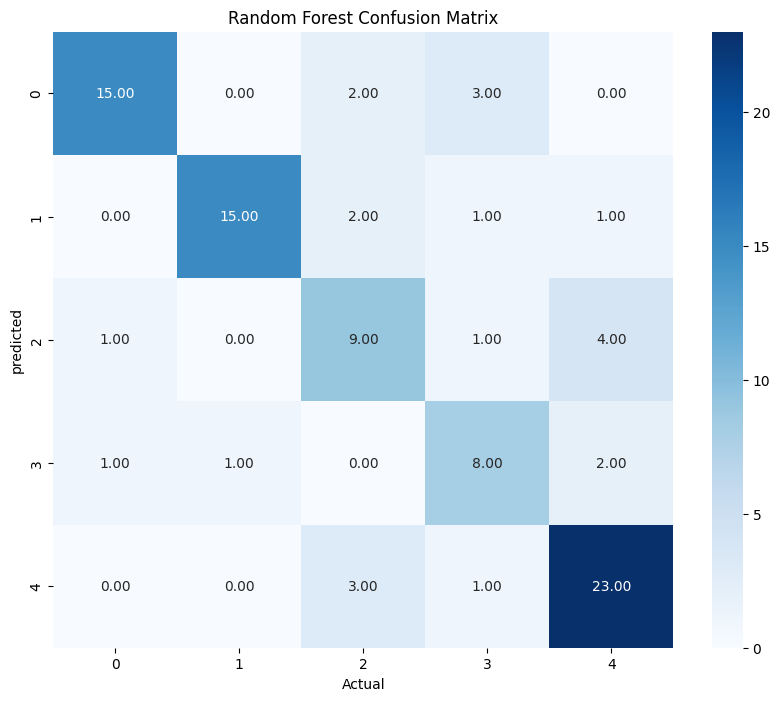

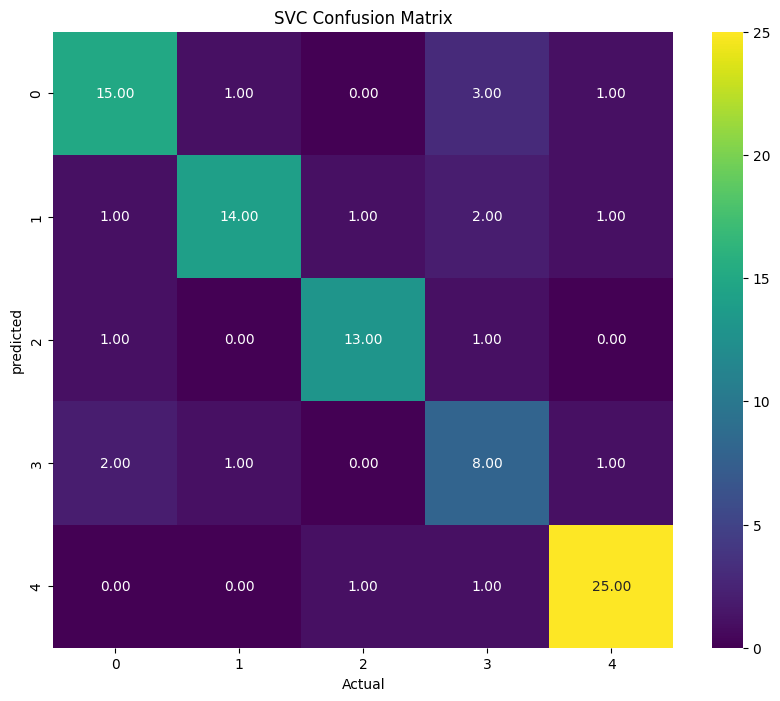

In [ ]:
#confusion matrix for both model

from sklearn.metrics import confusion_matrix

cm_rfc=confusion_matrix(y_test,y_pred_rfc)

cm_svc=confusion_matrix(y_test,y_pred_svc)

plt.figure(figsize=(10,8))
sns.heatmap(cm_rfc, annot=True,cmap='Blues',fmt='.2f')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.show()

plt.figure(figsize=(10,8))
sns.heatmap(cm_svc, annot=True,cmap='viridis',fmt='.2f')
plt.title('SVC Confusion Matrix')
plt.xlabel('Actual')
plt.ylabel('predicted')
plt.show()

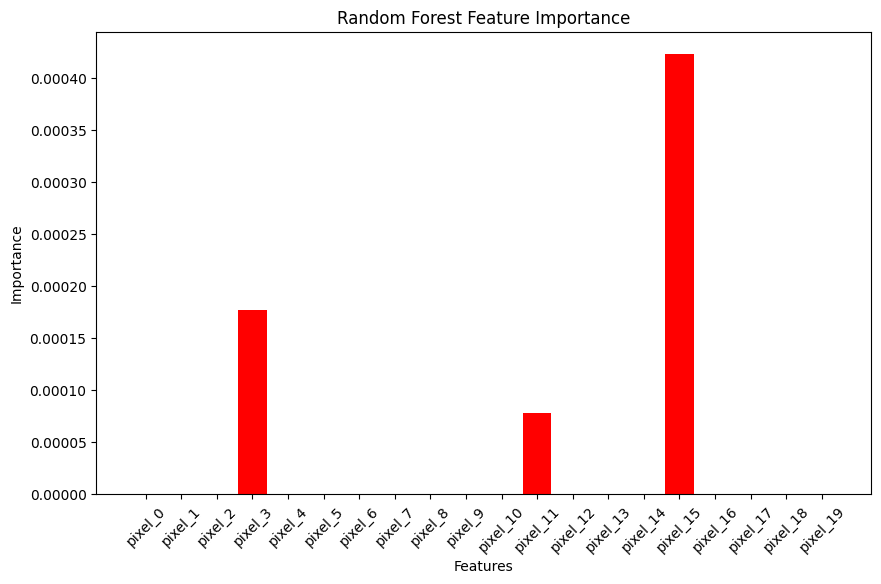

In [ ]:
#feature importance visualization

#created a Dataframe with X_scaled

# X_scaled= (309, 12288) and shape[1]=12288(features)

pixel_columns=[f"pixel_{i}" for i in range(X_scaled.shape[1])]

X_scaled_df=pd.DataFrame(X_scaled,columns=pixel_columns)

model_rfc.fit(x_train,y_train)

importances=model_rfc.feature_importances_

feature_importances_df=pd.DataFrame({'feature':X_scaled_df.columns,'importance':importances})



# Bar plot for feature importance

plt.figure(figsize=(10,6))

plt.bar(feature_importances_df['feature'].head(20),feature_importances_df['importance'].head(20),color='red')

plt.xlabel('Features')

plt.ylabel('Importance')

plt.title('Random Forest Feature Importance')

plt.xticks(rotation=45)

plt.show()

In [ ]:
#New image prediction

def preprocess_image(image_path):

    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (64, 64))

    img_array = img.astype("float32") / 255.0

    img_flat = img_array.flatten().reshape(1, -1)

    img_scaled = scaler.transform(img_flat)

    return img_scaled


def predict_image_class(image_path):

    processed_img = preprocess_image(image_path)


    prediction = model_rfc.predict(processed_img)[0]

    return prediction

In [ ]:
image_path="/content/images/dollar_bill/image_0030.jpg"

preprocess_image(image_path)

predicted_class = predict_image_class(image_path)
print(f"The predicted class for the image is: {predicted_class}")

The predicted class for the image is: sunflower
